# BDD100K Dataset Analysis

This notebook performs exploratory data analysis (EDA) on the BDD100K object detection dataset.

The analysis includes:

- Building object-level DataFrames
- Class distribution analysis
- Bounding box statistics
- Occlusion and truncation analysis
- Scene metadata analysis
- Train vs Validation comparison
- Data quality validation

Outputs are saved as CSV reports and visualization figures.

In [1]:
from pathlib import Path

import pandas as pd

from src.analysis.bbox_stats import BBoxStats
from src.analysis.class_stats import ClassStats
from src.analysis.occlusion_stats import OcclusionStats
from src.analysis.scene_stats import SceneStats
from src.analysis.train_val_comparison import TrainValComparison

from src.ingestion.dataframe_builder import DataFrameBuilder
from src.ingestion.parser import BDDParser

from src.utils.paths import REPORT_DIR, TRAIN_LABELS, VAL_LABELS

from src.utils.plotting import (
    plot_aspect_ratio_histogram,
    plot_bbox_area_histogram,
    plot_bbox_area_log_histogram,
    plot_category_distribution,
    plot_class_distribution,
    plot_occlusion_by_class,
    plot_occlusion_distribution,
    plot_train_val_comparison,
)

In [2]:
#Helper function
from IPython.display import Image, display

def save_and_show(plot_func, df, output_path):
    plot_func(df, output_path)
    display(Image(filename=output_path))

In [3]:
FIGURE_DIR = Path("outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Figures directory:", FIGURE_DIR)
print("Reports directory:", REPORT_DIR)

Figures directory: outputs/figures
Reports directory: /Volumes/Extreme Pro/Files/Github/Applied_cv/bdd100k-perception/outputs/reports


## Build Object-Level DataFrame

BDD100K annotations are parsed and flattened into a single DataFrame where
each row corresponds to one object instance.

In [4]:
def build_split_dataframe(label_path: Path, output_filename: str):
    """
    Parse BDD100K labels and create an object-level dataframe.
    """

    print(f"\nProcessing {output_filename}")

    parser = BDDParser()
    scenes = parser.load_directory(label_path)

    print(f"Loaded {len(scenes):,} scenes")

    builder = DataFrameBuilder()
    df = builder.build(scenes)

    print(f"Generated {len(df):,} objects")

    output_file = REPORT_DIR / output_filename

    builder.save_csv(df, output_file)

    print(f"Saved: {output_file}")

    return df

In [5]:
## Create only one time to save time, since it takes a while to parse the labels and build the dataframe
# train_df = build_split_dataframe(
#     TRAIN_LABELS,
#     "train_objects.csv"
# )

# train_df.head()

In [6]:
## Create only one time to save time, since it takes a while to parse the labels and build the dataframe
# val_df = build_split_dataframe(
#     VAL_LABELS,
#     "val_objects.csv"
# )

# val_df.head()

In [7]:
train_df = pd.read_csv(
    REPORT_DIR / "train_objects.csv"
)

val_df = pd.read_csv(
    REPORT_DIR / "val_objects.csv"
)

## Initial Validation Checks

Verify:

- Data types
- Missing values
- Class frequencies
- Dataset size

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288010 entries, 0 to 1288009
Data columns (total 16 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   image_name    1288010 non-null  object 
 1   weather       1288010 non-null  object 
 2   scene         1288010 non-null  object 
 3   timeofday     1288010 non-null  object 
 4   category      1288010 non-null  object 
 5   x1            1288010 non-null  float64
 6   y1            1288010 non-null  float64
 7   x2            1288010 non-null  float64
 8   y2            1288010 non-null  float64
 9   width         1288010 non-null  float64
 10  height        1288010 non-null  float64
 11  occluded      1288010 non-null  bool   
 12  truncated     1288010 non-null  bool   
 13  is_valid_box  1288010 non-null  bool   
 14  area          1288010 non-null  float64
 15  aspect_ratio  1288010 non-null  float64
dtypes: bool(3), float64(8), object(5)
memory usage: 131.4+ MB


In [9]:
train_df["category"].value_counts().head(100)

category
car              713917
traffic sign     239893
traffic light    186224
person            91405
truck             30003
bus               11684
bike               7225
rider              4521
motor              3002
train               136
Name: count, dtype: int64

In [10]:
train_df["aspect_ratio"].describe()

count    1.288010e+06
mean     1.216780e+00
std      9.450749e-01
min      1.510368e-03
25%      7.368421e-01
50%      1.100000e+00
75%      1.486842e+00
max      4.968251e+02
Name: aspect_ratio, dtype: float64

In [11]:
train_df["area"].describe()

count    1.288010e+06
mean     6.785696e+03
std      2.288662e+04
min      8.714117e-01
25%      3.047444e+02
50%      8.177928e+02
75%      3.026594e+03
max      9.177098e+05
Name: area, dtype: float64

In [12]:
train_df.isnull().sum()

image_name      0
weather         0
scene           0
timeofday       0
category        0
x1              0
y1              0
x2              0
y2              0
width           0
height          0
occluded        0
truncated       0
is_valid_box    0
area            0
aspect_ratio    0
dtype: int64

## Class Distribution Analysis

Analyze frequency of object categories.

In [13]:
class_stats = ClassStats(train_df)

class_dist = class_stats.class_distribution()

class_dist.head()

,category,count,percentage
0,car,713917,55.427908
1,traffic sign,239893,18.625088
2,traffic light,186224,14.458273
3,person,91405,7.096606
4,truck,30003,2.329407


In [15]:
print(class_stats.summary())

{'num_classes': 10, 'num_objects': 1288010, 'largest_class': 'car', 'largest_count': 713917, 'smallest_class': 'train', 'smallest_count': 136, 'imbalance_ratio': np.float64(5249.389705882353)}


In [14]:
class_dist.to_csv(
    REPORT_DIR / "train_class_distribution.csv",
    index=False
)

plot_class_distribution(
    class_dist,
    FIGURE_DIR / "train_class_distribution.png"
)

## Bounding Box Statistics

Analyze:

- Object area
- Object size
- Aspect ratios

In [15]:
bbox_stats = BBoxStats(train_df)

print(bbox_stats.area_summary())
print(bbox_stats.size_distribution())

{'mean_area': np.float64(6785.695737241945), 'median_area': np.float64(817.7927734372107), 'min_area': np.float64(0.8714116864181584), 'max_area': np.float64(917709.770977253)}
area
small     710396
medium    414421
large     163193
Name: count, dtype: int64


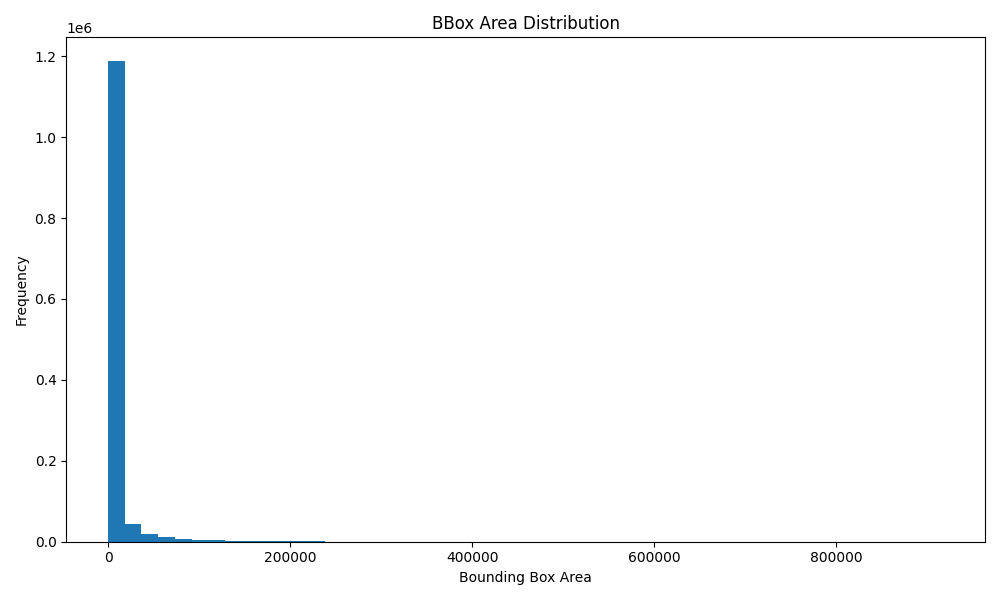

In [40]:
save_and_show(plot_bbox_area_histogram,
    train_df,
    FIGURE_DIR / "train_bbox_area_histogram.png"
)

In [16]:
plot_bbox_area_log_histogram(
    train_df,
    FIGURE_DIR / "train_bbox_area_log_histogram.png"
)

In [17]:
plot_aspect_ratio_histogram(
    train_df,
    FIGURE_DIR / "train_aspect_ratio_histogram.png"
)

## Occlusion and Truncation Analysis

In [18]:
occ_stats = OcclusionStats(train_df)

print(occ_stats.overall_occlusion_rate())
print(occ_stats.truncation_rate())

{'total_objects': 1288010, 'occluded_objects': 609273, 'occlusion_rate': np.float64(47.3)}
{'truncated_objects': 89341, 'truncation_rate': np.float64(6.94)}


In [19]:
occ_df = occ_stats.occlusion_by_class()

occ_df.head()

,category,occluded
0,rider,89.161690
1,bike,83.820069
2,motor,76.515656
3,car,67.734905
4,bus,65.516946


In [20]:
plot_occlusion_distribution(
    train_df,
    FIGURE_DIR / "train_occlusion_distribution.png"
)

In [21]:
plot_occlusion_by_class(
    occ_df,
    FIGURE_DIR / "train_occlusion_by_class.png"
)

## Scene Metadata Analysis

Analyze:

- Weather
- Time of day
- Scene type

In [22]:
scene_stats = SceneStats(train_df)

weather_df = scene_stats.weather_distribution()
time_df = scene_stats.timeofday_distribution()
scene_df = scene_stats.scene_distribution()

In [23]:
weather_df

,weather,count
0,clear,653843
1,overcast,185140
2,undefined,161023
3,snowy,99680
4,partly cloudy,97018
5,rainy,89446
6,foggy,1860


In [24]:
scene_df

,scene,count
0,city street,890290
1,highway,253983
2,residential,133448
3,parking lot,5655
4,undefined,3471
5,tunnel,880
6,gas stations,283


In [25]:
plot_category_distribution(
    weather_df,
    "weather",
    "count",
    "Weather Distribution",
    FIGURE_DIR / "train_weather_distribution.png"
)

In [26]:
plot_category_distribution(
    time_df,
    "timeofday",
    "count",
    "Time of Day Distribution",
    FIGURE_DIR / "train_timeofday_distribution.png"
)

In [27]:
plot_category_distribution(
    scene_df,
    "scene",
    "count",
    "Scene Distribution",
    FIGURE_DIR / "train_scene_distribution.png"
)

## Data Quality Validation

Detect:

- Zero-area boxes
- Negative dimensions
- Invalid annotations

In [28]:
def data_quality_report(df, split_name="unknown"):
    print(f"\nDATA QUALITY REPORT: {split_name}")
    print("=" * 50)

    conditions = {
        "zero_area": df["area"] == 0,
        "negative_area": df["area"] < 0,
        "zero_width": df["width"] == 0,
        "zero_height": df["height"] == 0,
        "negative_width": df["width"] < 0,
        "negative_height": df["height"] < 0,
    }

    for issue_name, mask in conditions.items():
        print(f"{issue_name}: {mask.sum()}")

    invalid_frames = []

    for issue_name, mask in conditions.items():
        if mask.any():
            invalid_df = df.loc[mask].copy()
            invalid_df["issue_type"] = issue_name
            invalid_frames.append(invalid_df)

    if not invalid_frames:
        return pd.DataFrame(columns=[*df.columns, "issue_type"])

    return (
        pd.concat(invalid_frames, ignore_index=True)
        .drop_duplicates()
    )

In [29]:
invalid_boxes = data_quality_report(
    train_df,
    split_name="train"
)

invalid_boxes.head()


DATA QUALITY REPORT: train
zero_area: 0
negative_area: 0
zero_width: 0
zero_height: 0
negative_width: 0
negative_height: 0


,image_name,weather,scene,timeofday,category,x1,y1,x2,y2,width,height,occluded,truncated,is_valid_box,area,aspect_ratio,issue_type


## Train vs Validation Comparison

Evaluate distribution consistency between training and validation splits.

In [30]:
comparison = TrainValComparison(
    train_df,
    val_df
)

In [31]:
class_cmp = comparison.compare_classes()

class_cmp.head()

,category,train_pct,val_pct
0,car,55.427908,55.251555
1,traffic sign,18.625088,18.815692
2,traffic light,14.458273,14.491230
3,person,7.096606,7.148324
4,truck,2.329407,2.288089


In [32]:
plot_train_val_comparison(
    class_cmp,
    "category",
    FIGURE_DIR / "train_val_class.png",
    "Train vs Validation Classes"
)

In [33]:
weather_cmp = comparison.compare_column("weather")

plot_train_val_comparison(
    weather_cmp,
    "weather",
    FIGURE_DIR / "train_val_weather.png",
    "Train vs Validation Weather"
)

# Conclusions

Key observations:

1. Most frequent classes are ...
2. Bounding box areas are heavily skewed toward small objects.
3. Occlusion is significant for traffic participants.
4. Weather and scene distributions are balanced between train and validation.
5. Data quality checks indicate minimal annotation issues.

These findings help guide model selection, augmentation strategy, and evaluation methodology.

## Object detection metrics

In [41]:
from ultralytics import YOLO

model = YOLO(
    "/Volumes/Extreme Pro/Files/Github/Applied_cv/bdd100k-perception/runs/detect/outputs/training/yolov8n_bdd100k/weights/best.pt"
)

metrics = model.val(
    data="/Volumes/Extreme Pro/Files/Github/Applied_cv/bdd100k-perception/configs/yolo_dataset.yaml"
)

Ultralytics 8.4.60 🚀 Python-3.11.15 torch-2.12.0 CPU (Apple M2)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.5 ms, read: 118.5±29.1 MB/s, size: 65.5 KB)
val: Scanning /Volumes/Extreme Pro/Files/Github/Applied_cv/datasets/bdd100k/labels/100k/val.cache... 10000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10000/10000 238.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 625/625 2.5s/it 26:04<2.2s
                   all      10000     185526      0.437      0.297      0.295      0.155
                   car       9879     102506      0.603      0.628      0.639      0.374
                 truck       2689       4245       0.42      0.437      0.384      0.254
                   bus       1242       1597      0.379      0.375      0.345      0.258
                person       3220      13262       0.46      0.425        0.4      0.178
       